In [1]:
import pandas as pd
from skimpy import skim
from dfsummary import dfsummary
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
boston = pd.read_csv("dataset/BostonHousing.csv")
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
print(boston)

        crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273   

     ptratio       b  lstat  medv  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14  21.6  
2       17.8  3

# Preparing the dataset

In [4]:
boston.isna().sum() / len(boston) * 100

crim       0.000000
zn         0.000000
indus      0.000000
chas       0.000000
nox        0.000000
rm         0.988142
age        0.000000
dis        0.000000
rad        0.000000
tax        0.000000
ptratio    0.000000
b          0.000000
lstat      0.000000
medv       0.000000
dtype: float64

In [5]:
skim(boston)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 506    │ │ float64     │ 11    │                                                          │
│ │ Number of columns │ 14     │ │ int64       │ 3     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column  ┃ NA ┃ NA %               ┃ mean    ┃ sd     ┃ p0      ┃ p25     ┃ p50    ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │  crim   │  0 │                  0 │   3.614 │  8.602 │ 0.00632 │ 0.08204 │ 0.2565 │ 3.677 │ 88.98 │   ▇    │  │
│ │   zn    │  0 │                  0 │   11.36 │  23.32 │       0 │       0 │      0 │  12.5 │   100 │   ▇▁   │  │
│ │  indus  │  0 │                  0 │   11.14 │   6.86 │    0.46 │    5.19 │   9.69 │  18.1 │ 27.74 │ ▇▇▃▇▃▁ │  │
│ │  chas   │  0 │                  0 │ 0.06917 │  0.254 │       0 │       0 │      0 │     0 │     1 │ ▇    ▁ │  │
│ │   nox   │  0 │                  0 │  0.5547 │ 0.1159 │   0.385 │   0.449 │  0.538 │ 0.624 │ 0.871 │ ▇▇▅▃▂▁ │  │
│ │   rm    │  5 │ 0.9881422924901185 │   6.284 │ 0.7056 │   3.561 │   5.884 │  6.208 │ 6.625 │  8.78 │  ▁▇▇▂▁ │  │
│ │   age   │  0 │                  0 │   68.57 │  28.15 │     2.9 │   45.02 │   77.5 │ 94.07 │   100 │ ▁▂▂▂▃▇ │  │
│ │   dis   │  0 │                  0 │   3.795 │  2.106 │    1.13 │     2.1 │  3.207 │ 5.188 │ 12.13 │  ▇▅▃▁  │  │
│ │   rad   │  0 │                  0 │   9.549 │  8.707 │       1 │       4 │      5 │    24 │    24 │ ▇▇   ▆ │  │
│ │   tax   │  0 │                  0 │   408.2 │  168.5 │     187 │     279 │    330 │   666 │   711 │ ▅▇▅  ▆ │  │
│ │ ptratio │  0 │                  0 │   18.46 │  2.165 │    12.6 │    17.4 │  19.05 │  20.2 │    22 │ ▁▂▂▅▇▂ │  │
│ │    b    │  0 │                  0 │   356.7 │  91.29 │    0.32 │   375.4 │  391.4 │ 396.2 │ 396.9 │      ▇ │  │
│ │  lstat  │  0 │                  0 │   12.65 │  7.141 │    1.73 │    6.95 │  11.36 │ 16.96 │ 37.97 │ ▇▇▆▂▁  │  │
│ │  medv   │  0 │                  0 │   22.53 │  9.197 │       5 │   17.02 │   21.2 │    25 │    50 │ ▂▇▇▃▁▁ │  │
│ └─────────┴────┴────────────────────┴─────────┴────────┴─────────┴─────────┴────────┴───────┴───────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [6]:
def dataframe_corr(dataframe, corr_name = 'pearson'):
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(dataframe.corr(method=corr_name), annot=True, cmap="coolwarm")
    plt.show()

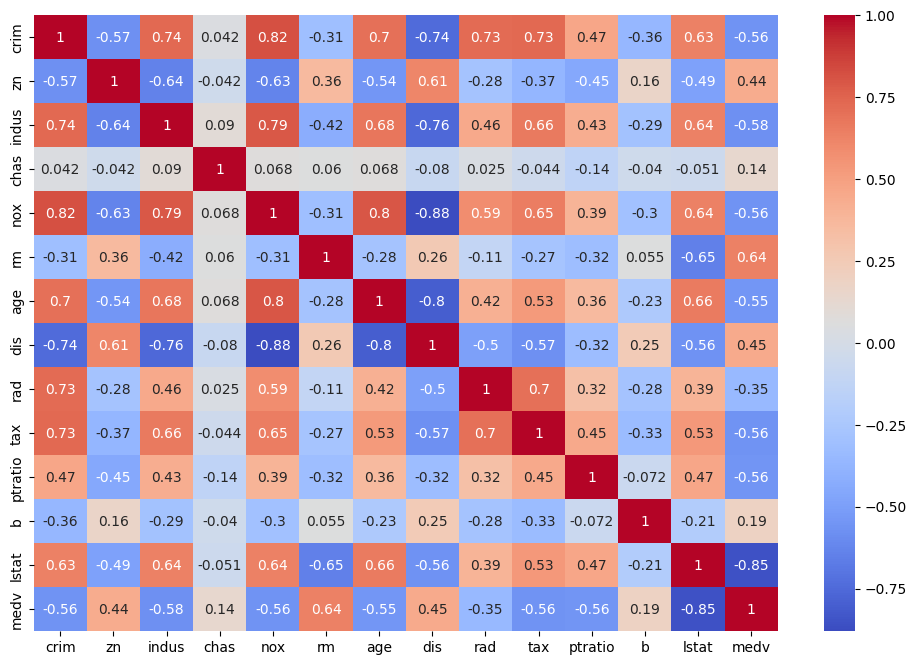

In [7]:
dataframe_corr(boston, 'spearman')

In [8]:
boston.dropna(inplace=True)

c:\Users\hassa\Documents\Projects\Boston House Pricing\boston_house_pricing\.venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


<Axes: xlabel='zn', ylabel='medv'>

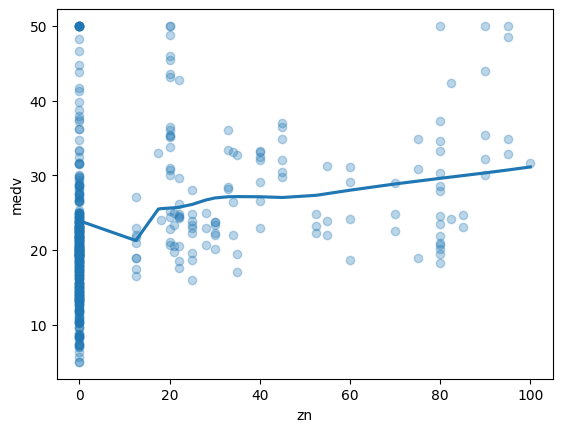

In [9]:
sns.regplot(data=boston, x="zn", y="medv", lowess=True, scatter_kws={"alpha": 0.3})

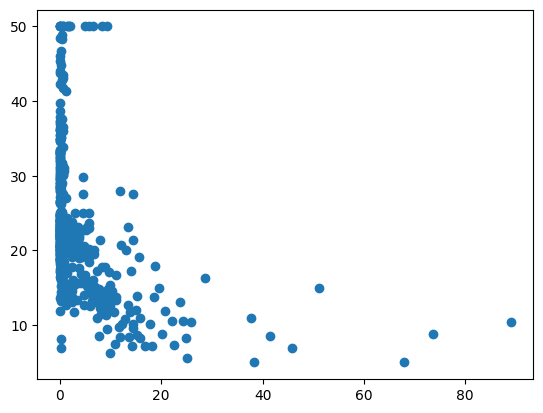

In [13]:
plt.scatter(boston['crim'], boston['medv'])